In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RESULTS_DIR = Path("results")

EVAL_TRAITS = [
    "Alkali spreading value",
    "Amylose content",
    "Panicle number per plant",
    "Protein content",
    "Seed length",
    "Seed number per panicle",
]

SHORT_LABELS = [
    "Alkali spreading",
    "Amylose",
    "Panicle no.",
    "Protein",
    "Seed length",
    "Seed no./panicle",
]

# ── Load grid-search results (one row per eval trait, best model) ─────────────
emb_df = pd.read_csv(RESULTS_DIR / "emb_grid_search_results.csv")   # PCC column
svd_df = pd.read_csv(RESULTS_DIR / "svd_grid_search_results.csv")   # PCC column

# # ── Load baseline results (all models × all traits) and take best per trait ──
# baseline_full = pd.read_csv(RESULTS_DIR / "baseline_results.csv")   # "Pearson r" column
# baseline_df = (
#     baseline_full[baseline_full["Trait"].isin(EVAL_TRAITS)]
#     .sort_values("Pearson r", ascending=False)
#     .groupby("Trait", sort=False)
#     .first()
#     .reset_index()
#     .rename(columns={"Pearson r": "PCC"})
# )

# Align all three to the canonical EVAL_TRAITS order
emb_df      = emb_df.set_index("Trait").loc[EVAL_TRAITS].reset_index()
svd_df      = svd_df.set_index("Trait").loc[EVAL_TRAITS].reset_index()
# baseline_df = baseline_df.set_index("Trait").loc[EVAL_TRAITS].reset_index()

METHODS = [
    ("Embedding (PCA + grid search)",  emb_df,      "#4e79a7"),
    ("SNP SVD + grid search",          svd_df,      "#f28e2b"),
    # ("SNP baseline (best of Ridge/Lasso/RF)", baseline_df, "#59a14f"),
]

print("Loaded results:")
for label, df, _ in METHODS:
    print(f"  {label}: {len(df)} traits, mean PCC={df['PCC'].mean():.3f}")

Loaded results:
  Embedding (PCA + grid search): 6 traits, mean PCC=0.542
  SNP SVD + grid search: 6 traits, mean PCC=0.661


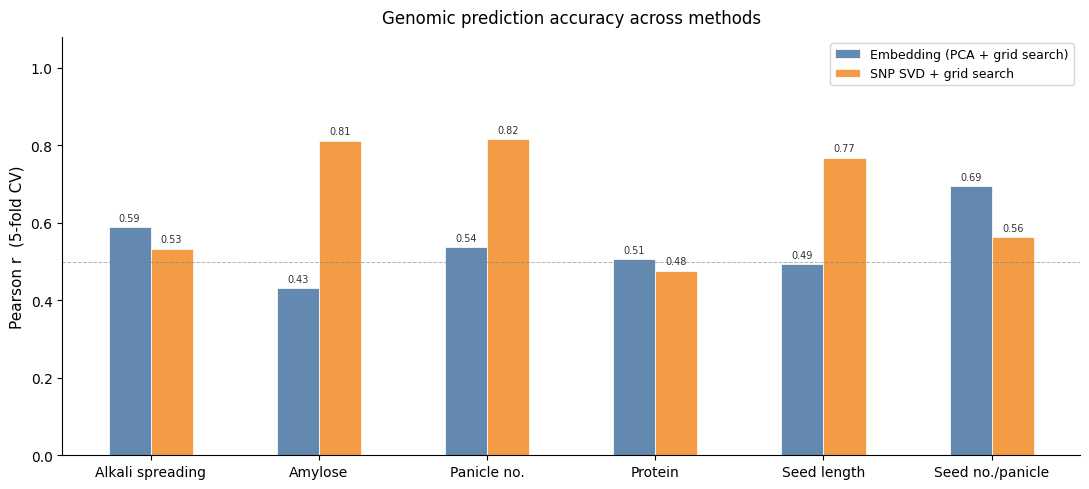

In [3]:
# ── Grouped bar chart: one group per trait, one bar per method ────────────────
n_traits  = len(EVAL_TRAITS)
n_methods = len(METHODS)
width = 0.25
x = np.arange(n_traits)

fig, ax = plt.subplots(figsize=(11, 5))

for i, (label, df, color) in enumerate(METHODS):
    offset = (i - (n_methods - 1) / 2) * width
    bars = ax.bar(x + offset, df["PCC"].values, width,
                  label=label, color=color, alpha=0.88, edgecolor="white", linewidth=0.6)
    for bar, pcc in zip(bars, df["PCC"].values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.012,
            f"{pcc:.2f}",
            ha="center", va="bottom", fontsize=7, color="#333333",
        )

ax.set_xticks(x)
ax.set_xticklabels(SHORT_LABELS, fontsize=10)
ax.set_ylabel("Pearson r  (5-fold CV)", fontsize=11)
ax.set_ylim(0, 1.08)
ax.axhline(0, color="black", linewidth=0.5)
ax.axhline(0.5, color="gray", linewidth=0.7, linestyle="--", alpha=0.6)
ax.legend(fontsize=9, loc="upper right")
ax.set_title("Genomic prediction accuracy across methods", fontsize=12, pad=10)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "comparison_grouped_bar.pdf", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# ── Per-method subplots: one bar chart per method, shared y-axis ──────────────
fig, axes = plt.subplots(1, n_methods, figsize=(14, 4.5), sharey=True)

for ax, (label, df, color) in zip(axes, METHODS):
    pcc_vals = df["PCC"].values
    bar_colors = [color if p >= 0.5 else "#cccccc" for p in pcc_vals]
    bars = ax.bar(SHORT_LABELS, pcc_vals, color=bar_colors,
                  edgecolor="white", linewidth=0.6, alpha=0.9)
    for bar, pcc in zip(bars, pcc_vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.015,
            f"{pcc:.2f}",
            ha="center", va="bottom", fontsize=8.5,
        )
    ax.set_title(label, fontsize=9.5, pad=8)
    ax.set_ylim(0, 1.08)
    ax.set_xticklabels(SHORT_LABELS, rotation=30, ha="right", fontsize=9)
    ax.axhline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.spines[["top", "right"]].set_visible(False)

axes[0].set_ylabel("Pearson r  (5-fold CV)", fontsize=11)
fig.suptitle("Genomic prediction accuracy by method", fontsize=12, y=1.02)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "per_method_bars.pdf", dpi=150, bbox_inches="tight")
plt.show()